# Financial Trading with Python, 2nd Edition
Cordell L. Tanny, CFA, FRM, FDP

## Chapter 5: Data Preparation
### Notebook 5.1: Data Preparation

Version: 1

Date of last revision: February 11, 2026

**Making Data Trustworthy**

*Note and recommendation: Very often, you might want to experiment on your own as you go through this notebook. We recommend you save a copy of this notebook before you start adding cells or changing anything. This way you always have a pristine copy to go back to.*

## 1.1 What is Data Preparation?

Raw financial data is never ready for analysis. Between downloading data and building a trading strategy, there is critical work that determines whether your results are meaningful or worthless.

Data preparation is the process of transforming raw data into analysis-ready data. This includes:

- Detecting and handling missing values
- Resampling data to different frequencies
- Identifying and addressing outliers
- Transforming prices into returns and other derived features
- Avoiding lookahead bias in your calculations

This is where most amateur quants fail. They skip straight to backtesting, never realizing their data has problems that invalidate every conclusion. Professionals know that the time spent here pays dividends later.

## 1.2 The Data Preparation Workflow

Data preparation follows a logical sequence:

- **Inspect** your raw data to understand its structure and identify obvious issues.

- **Align** multiple data sources to a common date range and frequency.

- **Clean** the data by handling missing values and outliers.

- **Transform** prices into returns, rolling statistics, and other derived features.

- **Validate** that your prepared data meets expectations before using it.

This workflow is iterative. You will often discover issues during transformation that send you back to the cleaning step. That is normal. The goal is a dataset you can trust.

## 1.3 Why We Use Simulated Data

Real financial data from major tickers like SPY or AAPL is often remarkably clean. Data vendors have already handled many issues before you see the data. This is good for trading but bad for learning.

To ensure you see the problems clearly, this notebook uses simulated data with intentionally injected issues. You will work with data that has:

- Missing values in various patterns
- Outliers of different types
- Frequency mismatches

At the end of the notebook, we will apply what we learned to our VIXY tail hedge case study. There, you will see that simple strategies often need minimal preparation. That is an important lesson too.

## 1.4 Creating Our Simulated Dataset

We will create a simulated price series that mimics realistic financial data but includes known issues we can study. First, let us import the libraries we need and set up our environment.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For winsorization
from scipy.stats import mstats

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


We import pandas and NumPy for data manipulation, matplotlib for visualization, and scipy's mstats module for winsorization (which we will cover in Section 4). Setting a random seed ensures our simulated data is reproducible.

Now we generate a simulated price series. We will create 1000 trading days of data with realistic properties: a slight upward drift, daily volatility, and occasional larger moves.

In [2]:
# Create date range (approximately 4 years of trading days)
dates = pd.date_range(start='2020-01-01', periods=1000, freq='B')

# Generate daily returns with realistic properties
# Mean daily return of ~0.04% (roughly 10% annual)
# Daily volatility of ~1.5% (roughly 24% annual)
daily_returns = np.random.normal(loc=0.0004, scale=0.015, size=1000)

# Convert returns to prices starting at 100
prices = 100 * np.cumprod(1 + daily_returns)

# Create the DataFrame
df_clean = pd.DataFrame({
    'price': prices
}, index=dates)

df_clean.index.name = 'date'

print(f"Created {len(df_clean)} rows of simulated price data")
print(f"Date range: {df_clean.index[0].date()} to {df_clean.index[-1].date()}")
df_clean.head(10)

Created 1000 rows of simulated price data
Date range: 2020-01-01 to 2023-10-31


,price
date,
2020-01-01,100.7851
2020-01-02,100.6164
2020-01-03,101.6341
2020-01-06,103.9967
2020-01-07,103.6730
2020-01-08,103.3504
2020-01-09,105.8399
2020-01-10,107.1006
2020-01-13,106.3892


We now have a clean price series with 1000 business days. The prices follow a random walk with slight upward drift, similar to a typical equity. This is our baseline. Next, we will create a copy and inject various data quality issues.

Let us create a working copy and inject the issues we want to study. We will add:

1. Random missing values (simulating data gaps)
2. A block of missing values (simulating a vendor outage)
3. A few extreme outliers (simulating data errors or extreme events)

In [3]:
# Create a working copy
df = df_clean.copy()

# 1. Inject random missing values (about 2% of data)
random_missing_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[random_missing_idx, 'price'] = np.nan

# 2. Inject a block of missing values (5 consecutive days)
block_start = df.index[200]
block_end = df.index[204]
df.loc[block_start:block_end, 'price'] = np.nan

# 3. Inject outliers (extreme values that could be data errors)
# One impossibly negative value
df.loc[df.index[400], 'price'] = -50

# One value that is 10x too high (like a decimal error)
df.loc[df.index[600], 'price'] = df_clean.loc[df.index[600], 'price'] * 10

# One value that is a sudden spike and recovery (flash crash style)
df.loc[df.index[800], 'price'] = df_clean.loc[df.index[800], 'price'] * 0.5

print("Issues injected:")
print(f"  - Random missing values: 20")
print(f"  - Block of missing values: 5 consecutive days")
print(f"  - Outliers: 3 (negative price, 10x spike, 50% drop)")

Issues injected:
  - Random missing values: 20
  - Block of missing values: 5 consecutive days
  - Outliers: 3 (negative price, 10x spike, 50% drop)


We now have a dataset with realistic data quality problems. The random missing values simulate sporadic data gaps. The block of missing values simulates a vendor outage or data feed interruption. The outliers simulate three different scenarios:

- A negative price (clearly impossible, must be a data error)
- A price 10x too high (could be a decimal point error)
- A sudden 50% drop (could be real like a flash crash, or could be an error)

This last case is the tricky one. In real financial data, you often cannot tell if an extreme value is an error or a genuine market event. We will discuss this dilemma in Section 4.

Before we start cleaning, let us establish a baseline understanding of our data using the inspection techniques from Chapter 2.

In [4]:
# Basic inspection
print("=== Data Info ===")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Index type: {type(df.index)}")
print()

# Check for missing values
print("=== Missing Values ===")
print(f"Total missing: {df['price'].isna().sum()}")
print(f"Percentage missing: {df['price'].isna().mean() * 100:.2f}%")
print()

# Basic statistics
print("=== Basic Statistics ===")
print(df.describe())

=== Data Info ===
Shape: (1000, 1)
Date range: 2020-01-01 to 2023-10-31
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

=== Missing Values ===
Total missing: 25
Percentage missing: 2.50%

=== Basic Statistics ===
          price
count  975.0000
mean   118.5217
std     40.2010
min    -50.0000
25%    102.8113
50%    111.7550
75%    124.3589
max   1068.6634


The inspection reveals our injected issues:

- 25 missing values (20 random + 5 in the block)
- A minimum value of -50 (our impossible negative price)
- A maximum that is far higher than expected (our 10x spike)

The describe() output already flags problems. The min value is negative (impossible for a price), and the range between min and max is suspiciously large. In real data, these would be red flags requiring investigation.

Now let us work through each type of issue systematically.

## 2. Handling Missing Values



### 2.1 Why Missing Data Matters

Missing values are silent killers in financial analysis. They do not throw errors. They do not stop your code. They simply propagate through your calculations, producing results that look reasonable but are wrong.

Consider calculating a 20-day moving average. If day 15 is missing, pandas will still compute a value, but it will be based on 19 days, not 20. Your signal is now inconsistent. Worse, if you calculate returns from prices and a price is missing, you get NaN for that day AND the next day (because you cannot compute a return without two consecutive prices).

The first step is always detection. You cannot fix what you do not know is broken.

### 2.2 Types of Missing Data

Not all missing data is the same. The cause determines the solution.

- Structural missing is expected and benign. Stock markets are closed on weekends and holidays. If you request daily data, those dates simply do not exist. This is not a problem to fix.

- Data gaps are problematic. Your data vendor had an outage. A ticker was halted for a day. The API returned partial data. These gaps need to be addressed.

- Inception differences occur when combining multiple assets. SPY has data back to 1993. VIXY only started in 2011. If you try to analyze them together from 2000, VIXY will have missing values for the first 11 years.

Each type requires a different approach.

### 2.3 Detection Methods

Let us examine our simulated data to find the missing values we injected. Pandas provides several methods for detection.

#### 2.3.1 Counting Missing Values

The simplest check is counting how many values are missing.

In [5]:
# Count missing values by column
print("=== Missing Values by Column ===")
print(df.isna().sum())
print()

# Count rows with any missing value
print("=== Rows with Missing Values ===")
rows_with_missing = df.isna().any(axis=1).sum()
print(f"Rows with at least one missing value: {rows_with_missing}")

=== Missing Values by Column ===
price    25
dtype: int64

=== Rows with Missing Values ===
Rows with at least one missing value: 25


The `.isna()` method returns a boolean DataFrame where True indicates a missing value. Summing this gives us counts. We have 25 missing values in the price column, which matches what we injected (20 random + 5 in the block). For a single-column DataFrame like ours, the row count and column count are the same. With multiple columns, a row might have some values present and others missing.

#### 2.3.2 Locating Missing Values

Knowing the count is not enough. We need to find which specific dates are affected.

In [6]:
# Find the actual dates with missing values
missing_dates = df[df['price'].isna()].index
print(f"Dates with missing values ({len(missing_dates)} total):")
for d in missing_dates:
    print(f"  {d.date()}")

Dates with missing values (25 total):
  2020-02-26
  2020-04-22
  2020-05-06
  2020-08-25
  2020-09-10
  2020-10-05
  2020-10-07
  2020-10-08
  2020-10-09
  2020-10-12
  2020-10-13
  2020-11-05
  2020-11-10
  2020-12-08
  2021-04-09
  2021-10-14
  2021-11-01
  2021-12-08
  2022-01-27
  2022-03-10
  2022-03-31
  2022-05-26
  2023-02-23
  2023-05-31
  2023-08-03


Now we can see exactly which dates are affected. Notice the cluster from 2020-10-07 through 2020-10-13 (five consecutive business days, skipping the weekend). That is our simulated vendor outage. The date 2020-10-05 happens to be one of the random missing values that landed close to the block. The remaining dates are scattered across 2020 through 2023.

For larger datasets, a visual representation helps identify patterns. A heatmap can reveal whether missing values are random or clustered.

#### 2.3.3 Visualizing Missing Data Patterns

For larger datasets, a visual representation helps identify patterns. A heatmap can reveal whether missing values are random or clustered.

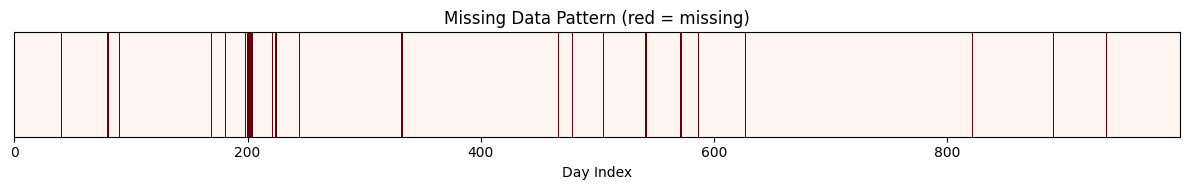

In [7]:
# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(12, 2))

# Create a binary array: 1 for missing, 0 for present
missing_pattern = df['price'].isna().values.reshape(1, -1)

ax.imshow(missing_pattern, aspect='auto', cmap='Reds', interpolation='none')
ax.set_xlabel('Day Index')
ax.set_yticks([])
ax.set_title('Missing Data Pattern (red = missing)')
plt.tight_layout()
plt.show()

The heatmap shows red vertical lines where data is missing. The cluster around index 200 stands out immediately. That is our block of consecutive missing values plus one random missing value that happened to land nearby. The remaining red lines are scattered throughout the series with no obvious pattern, which is what we expect from random missing values.

In real data, this type of visualization quickly reveals whether you have sporadic gaps or systematic outages.

### 2.4 Handling Strategies

Once you have found missing values, you need to decide what to do with them. There is no universal answer. The right approach depends on the cause of the missing data and how you plan to use it. We will cover four strategies: dropping, forward filling, interpolation, and leaving as NaN.

#### 2.4.1 Dropping Missing Values

The simplest approach is to remove rows with missing values. This is appropriate when missing values are rare and randomly distributed.

In [8]:
# Drop rows with missing values
df_dropped = df.dropna()

print(f"Original rows: {len(df)}")
print(f"After dropna(): {len(df_dropped)}")
print(f"Rows removed: {len(df) - len(df_dropped)}")

Original rows: 1000
After dropna(): 975
Rows removed: 25


We removed 25 rows, leaving 975. This is a small percentage (2.5%) so the data loss is acceptable. However, dropping creates gaps in your time series. If you calculate a 10-day rolling average, the calculation will span across the gap as if those days never existed. For many applications this is fine. For others, it is a problem.

#### 2.4.2 Forward Filling

Forward filling carries the last known value forward until a new value appears. This assumes yesterday's value is a reasonable proxy for today.

In [9]:
# Forward fill missing values
df_ffill = df.copy()
df_ffill['price'] = df_ffill['price'].ffill()

# Show a few rows around the block of missing values
print("Around the block of missing values (index 198-210):")
print(df_ffill.iloc[198:212])

Around the block of missing values (index 198-210):
              price
date               
2020-10-05  95.4948
2020-10-06  94.0154
2020-10-07  94.0154
2020-10-08  94.0154
2020-10-09  94.0154
2020-10-12  94.0154
2020-10-13  94.0154
2020-10-14  95.2336
2020-10-15  96.0074
2020-10-16  96.7857
2020-10-19  97.5722
2020-10-20 103.2500
2020-10-21 104.1754
2020-10-22 105.9916


Look at the dates from 2020-10-07 through 2020-10-13. These were our block of missing values. They all now show 94.0154, which is the value from 2020-10-06 (the last trading day before the gap). The price stayed flat for five days, then jumped to 95.2336 on 2020-10-14 when real data resumed.

Forward filling is common for price data because markets are continuous. If you do not know today's price, yesterday's price is a reasonable estimate. However, this introduces artificial flat periods that can distort volatility calculations and trading signals.

#### 2.4.3 Interpolation

Interpolation fills gaps by estimating values between known points. Linear interpolation draws a straight line between the last known value and the next known value.

In [10]:
# Interpolate missing values
df_interp = df.copy()
df_interp['price'] = df_interp['price'].interpolate(method='linear')

# Show the same rows for comparison
print("Around the block of missing values (index 198-210):")
print(df_interp.iloc[198:212])

Around the block of missing values (index 198-210):
              price
date               
2020-10-05  94.7551
2020-10-06  94.0154
2020-10-07  94.2184
2020-10-08  94.4214
2020-10-09  94.6245
2020-10-12  94.8275
2020-10-13  95.0305
2020-10-14  95.2336
2020-10-15  96.0074
2020-10-16  96.7857
2020-10-19  97.5722
2020-10-20 103.2500
2020-10-21 104.1754
2020-10-22 105.9916


Compare this to forward filling. Instead of flat values at 94.0154, we now see a gradual increase from 94.0154 (2020-10-06) to 95.2336 (2020-10-14). The interpolation drew a straight line between the known values and filled in the gaps evenly.

This looks smoother, but it is fabricated data. Markets do not move in straight lines. The real prices on those days could have spiked up and crashed back down, and we would never know. For trading signals, interpolated prices can create false patterns. Use interpolation with caution in financial applications.

#### 2.4.4 Why We Never Use Backfill

Pandas also offers backward filling with `.bfill()`, which fills missing values with the next known value. Do not use this for financial data.

In [11]:
# Backward fill - DO NOT USE for trading
df_bfill = df.copy()
df_bfill['price'] = df_bfill['price'].bfill()

# Show the same rows
print("Around the block of missing values (index 198-210):")
print(df_bfill.iloc[198:212])

Around the block of missing values (index 198-210):
              price
date               
2020-10-05  94.0154
2020-10-06  94.0154
2020-10-07  95.2336
2020-10-08  95.2336
2020-10-09  95.2336
2020-10-12  95.2336
2020-10-13  95.2336
2020-10-14  95.2336
2020-10-15  96.0074
2020-10-16  96.7857
2020-10-19  97.5722
2020-10-20 103.2500
2020-10-21 104.1754
2020-10-22 105.9916


Look at 2020-10-07 through 2020-10-13. They all show 95.2336, which is the value from 2020-10-14. Backfill used a future price to fill in past dates.

This is lookahead bias. On 2020-10-07, you would not have known that the price on 2020-10-14 would be 95.2336. If you use backfilled data to generate trading signals, your backtest will use information that was not available at decision time. Your results will look better than reality, and your strategy will fail when you trade it live.

Never use backfill for financial time series.

#### 2.4.5 Leaving as NaN

Sometimes the best approach is to leave missing values as NaN. This preserves the information that data is missing, which may be meaningful for your analysis.

In [12]:
# Create a flag column for missing values, then forward fill
df_flagged = df.copy()
df_flagged['was_missing'] = df_flagged['price'].isna().astype(int)
df_flagged['price_filled'] = df_flagged['price'].ffill()

# Show rows around the block
print("Flagged missing values (index 198-210):")
print(df_flagged[['price', 'was_missing', 'price_filled']].iloc[198:212])

Flagged missing values (index 198-210):
              price  was_missing  price_filled
date                                          
2020-10-05      NaN            1       95.4948
2020-10-06  94.0154            0       94.0154
2020-10-07      NaN            1       94.0154
2020-10-08      NaN            1       94.0154
2020-10-09      NaN            1       94.0154
2020-10-12      NaN            1       94.0154
2020-10-13      NaN            1       94.0154
2020-10-14  95.2336            0       95.2336
2020-10-15  96.0074            0       96.0074
2020-10-16  96.7857            0       96.7857
2020-10-19  97.5722            0       97.5722
2020-10-20 103.2500            0      103.2500
2020-10-21 104.1754            0      104.1754
2020-10-22 105.9916            0      105.9916


This hybrid approach gives you the best of both worlds. The original price column still contains NaN, preserving the truth about your data. The was_missing column flags which rows had missing values (1 = missing, 0 = present). The price_filled column provides a forward-filled version for calculations that require complete data.

Now you can make informed decisions downstream. You might exclude flagged rows from signal generation but include them in visualizations. You might analyze whether missing data clusters around specific market events. The flag gives you flexibility that simply filling or dropping does not.

### 2.5 When NOT to Fill

Filling missing values is not always appropriate. There are situations where filling creates problems worse than the missing data itself.

#### 2.5.1 Index Values Have No Previous Value

The VIX index is calculated from S&P 500 option prices during market hours. When the market is closed, there is no VIX. Forward filling VIX over a weekend implies that Friday's fear level persisted through Saturday and Sunday. It did not. There was simply no measurement.

For indices that represent real-time calculations, filling can create misleading continuity where none exists.

#### 2.5.2 Long Gaps Distort Reality

Forward filling over a one-day gap is reasonable. Forward filling over a month-long gap is not. If a stock was halted for 30 days during a corporate action, carrying forward the pre-halt price ignores everything that happened during that period.

In [13]:
# Demonstrate the problem with filling long gaps
df_long_gap = df_clean.copy()

# Create a 30-day gap
gap_start_idx = 300
gap_end_idx = 330
df_long_gap.iloc[gap_start_idx:gap_end_idx, 0] = np.nan

# Forward fill
df_long_gap_filled = df_long_gap.ffill()

# Show the price before, during, and after
print("Price before gap:")
print(f"  Index {gap_start_idx - 1}: {df_long_gap_filled.iloc[gap_start_idx - 1, 0]:.4f}")
print()
print("Price during gap (all filled with same value):")
print(f"  Index {gap_start_idx}: {df_long_gap_filled.iloc[gap_start_idx, 0]:.4f}")
print(f"  Index {gap_end_idx - 1}: {df_long_gap_filled.iloc[gap_end_idx - 1, 0]:.4f}")
print()
print("Price after gap:")
print(f"  Index {gap_end_idx}: {df_long_gap_filled.iloc[gap_end_idx, 0]:.4f}")
print()
print(f"Price jump when real data resumes: {df_long_gap_filled.iloc[gap_end_idx, 0] - df_long_gap_filled.iloc[gap_end_idx - 1, 0]:.4f}")

Price before gap:
  Index 299: 106.4492

Price during gap (all filled with same value):
  Index 300: 106.4492
  Index 329: 106.4492

Price after gap:
  Index 330: 122.0533

Price jump when real data resumes: 15.6041


The price sat at 106.4492 for 30 days, then jumped 15.60 points in a single day. In reality, that move happened gradually over the missing period. Any volatility calculation during the gap would show zero, then spike massively on the day data resumes. Any momentum signal would be wrong. The filled data bears no resemblance to what actually happened.

When you encounter gaps longer than a few days, consider excluding that period from your analysis entirely rather than filling it.

#### 2.5.3 Never Interpolate for Trading Signals

Interpolation creates prices that never existed. If your trading signal depends on whether the price crossed above 100, and interpolation fabricated a smooth path through 100, you will generate a signal based on a fictional event.

Forward filling is safer because at least the filled value was a real price at some point. Interpolated values are pure invention.

### 2.6 Decision Framework for Missing Values

Choosing how to handle missing values depends on the cause and your intended use. Here is a simple framework:

| Situation | Recommended Approach |
|-----------|---------------------|
| Random gaps, small percentage of data | Drop rows with `dropna()` |
| Short gaps (1-2 days), price data | Forward fill with `ffill()` |
| Different asset inception dates | Align to common date range with `dropna()` |
| Long gaps (weeks or more) | Exclude that period from analysis |
| Need to preserve missing information | Flag with a separate column |
| Index values (VIX, calculated indices) | Consider leaving as NaN or dropping |

The key question is always: will filling this value create something misleading? If yes, do not fill it.

## 3. Time Series Resampling



### 3.1 Why Resample?

Financial data comes in many frequencies: tick data, minute bars, daily closes, monthly returns. Your raw data frequency may not match what your strategy needs. Resampling converts data from one frequency to another.

Downsampling aggregates high-frequency data into lower frequency (daily to monthly). Upsampling attempts to create higher-frequency data from lower frequency (monthly to daily). In finance, downsampling is common and useful. Upsampling is rarely appropriate.

### 3.2 Downsampling (Aggregation)

Downsampling reduces the frequency of your data by aggregating multiple observations into one. The critical decision is how to aggregate. Different methods give different results.

In [14]:
# Start fresh with clean data for resampling examples
df_resample = df_clean.copy()

# Show the first few rows
print("Daily data (first 10 rows):")
print(df_resample.head(10))

Daily data (first 10 rows):
              price
date               
2020-01-01 100.7851
2020-01-02 100.6164
2020-01-03 101.6341
2020-01-06 103.9967
2020-01-07 103.6730
2020-01-08 103.3504
2020-01-09 105.8399
2020-01-10 107.1006
2020-01-13 106.3892
2020-01-14 107.2976


We have daily prices starting January 1, 2020. Notice the dates skip weekends (January 4-5 are missing because they were Saturday and Sunday). This is business day frequency, which is typical for equity data.

Now let us resample to monthly frequency using different aggregation methods.

#### 3.2.1 Aggregation Methods

The three most common aggregation methods are last, mean, and first. Each answers a different question about the period.

In [15]:
# Resample to monthly using different methods
monthly_last = df_resample.resample('ME').last()
monthly_mean = df_resample.resample('ME').mean()
monthly_first = df_resample.resample('ME').first()

# Compare the first 6 months
comparison = pd.DataFrame({
    'last': monthly_last['price'],
    'mean': monthly_mean['price'],
    'first': monthly_first['price']
})

print("Monthly resampling comparison (first 6 months):")
print(comparison.head(6))

Monthly resampling comparison (first 6 months):
              last     mean    first
date                                
2020-01-31 97.5450 102.0190 100.7851
2020-02-29 89.9150  92.4656  95.4993
2020-03-31 85.9405  86.9060  89.5449
2020-04-30 89.4008  89.6880  87.7232
2020-05-31 87.5665  88.0043  89.8775
2020-06-30 91.1290  89.4113  87.9398


Look at January 2020. The first price was 100.7851, the average price was 102.0190, and the last price was 97.5450. These are three different numbers that tell three different stories.

For financial analysis, we almost always use last. Here is why:

The last price is what you could actually trade at on month end. If you are calculating monthly returns, you need the price at the end of each month. An investor who held from January 31 to February 28 experienced the return from 97.5450 to 89.9150, not from some average to some other average.

The mean is dangerous because it represents a price that may never have existed. The average price in January was 102.0190, but you could not have bought or sold at that price on any specific day. Using mean prices to calculate returns produces returns that no investor could have achieved.

The first price has a similar problem. It tells you where the month started, not where it ended. If you are calculating month-over-month returns using first prices, you are measuring the return from the beginning of one month to the beginning of the next, which skips whatever happened at the end of each month.

Use last for prices. The only common exception is volume, where sum makes sense because total monthly volume is a me

#### 3.2.2 The Resampling Trap

A common mistake is calculating returns incorrectly after resampling. Let us see how this goes wrong.

In [16]:
# Calculate monthly returns three different ways
# Method 1: Resample to monthly last, then calculate returns (CORRECT)
monthly_prices = df_resample.resample('ME').last()
monthly_returns_correct = monthly_prices.pct_change()

# Method 2: Calculate daily returns, then average them (WRONG)
daily_returns = df_resample.pct_change()
monthly_returns_wrong = daily_returns.resample('ME').mean()

# Method 3: Calculate daily returns, then sum them (ALSO WRONG)
monthly_returns_sum = daily_returns.resample('ME').sum()

# Compare
comparison = pd.DataFrame({
    'correct (last then pct_change)': monthly_returns_correct['price'],
    'wrong (mean of daily returns)': monthly_returns_wrong['price'],
    'wrong (sum of daily returns)': monthly_returns_sum['price']
})

print("Monthly returns comparison (months 2-6):")
print(comparison.iloc[1:6])

Monthly returns comparison (months 2-6):
            correct (last then pct_change)  wrong (mean of daily returns)  \
date                                                                        
2020-02-29                         -0.0782                        -0.0040   
2020-03-31                         -0.0442                        -0.0020   
2020-04-30                          0.0403                         0.0019   
2020-05-31                         -0.0205                        -0.0009   
2020-06-30                          0.0407                         0.0019   

            wrong (sum of daily returns)  
date                                      
2020-02-29                       -0.0795  
2020-03-31                       -0.0434  
2020-04-30                        0.0422  
2020-05-31                       -0.0195  
2020-06-30                        0.0427  


Look at February 2020. The correct monthly return was -7.82%. The mean of daily returns shows -0.40%, which is completely wrong. The sum of daily returns shows -7.95%, which is close but still incorrect.

The mean is wrong because averaging daily returns does not give you the monthly return. If you gained 1% each day for 20 days, your monthly return is not 1%, it is about 22% due to compounding.

The sum is closer but still wrong because simple returns do not add, they compound. A 10% gain followed by a 10% loss is not 0%, it is -1%. The sum method would say 0%.

The correct approach is always: resample prices using `.last`, then calculate returns from the resampled prices.

#### 3.2.3 OHLC Aggregation

The `.ohlc()` method returns open, high, low, and close for each period. This preserves the full price range within each resampling period.

In [17]:
# OHLC aggregation - preserves price range within each period
monthly_ohlc = df_resample['price'].resample('ME').ohlc()
print("Monthly OHLC (first 6 months):")
print(monthly_ohlc.head(6))

Monthly OHLC (first 6 months):
               open     high     low   close
date                                        
2020-01-31 100.7851 107.2976 95.5600 97.5450
2020-02-29  95.4993  95.4993 88.4534 89.9150
2020-03-31  89.5449  89.5449 84.8655 85.9405
2020-04-30  87.7232  93.4833 87.6635 89.4008
2020-05-31  89.8775  91.4335 84.3231 87.5665
2020-06-30  87.9398  93.7144 85.3827 91.1290


The open is the first value in the period, close is the last, high is the maximum, and low is the minimum. This is how daily bars are constructed from intraday tick data, and the same logic applies to any downsampling.

Use `.ohlc()` when you need to preserve information about price movement within each period, such as when building candlestick charts or calculating period ranges.

### 3.3 Upsampling (Why You Usually Should Not)

Upsampling attempts to create higher-frequency data from lower-frequency data. For example, converting monthly prices to daily prices.

In [18]:
# Create monthly data
monthly_prices = df_resample.resample('ME').last()

# Attempt to upsample back to daily
daily_upsampled = monthly_prices.resample('D').ffill()

print("Monthly data (first 3 months):")
print(monthly_prices.head(3))
print()
print("Upsampled to daily (January - first 15 days):")
print(daily_upsampled.head(15))

Monthly data (first 3 months):
             price
date              
2020-01-31 97.5450
2020-02-29 89.9150
2020-03-31 85.9405

Upsampled to daily (January - first 15 days):
             price
date              
2020-01-31 97.5450
2020-02-01 97.5450
2020-02-02 97.5450
2020-02-03 97.5450
2020-02-04 97.5450
2020-02-05 97.5450
2020-02-06 97.5450
2020-02-07 97.5450
2020-02-08 97.5450
2020-02-09 97.5450
2020-02-10 97.5450
2020-02-11 97.5450
2020-02-12 97.5450
2020-02-13 97.5450
2020-02-14 97.5450


The price sits at 97.5450 from January 31 through February 14 and beyond. Every day in February shows the same value until we hit the February month-end observation. Then it jumps to 89.9150.

This data is useless. We have fabricated 28 days of fake prices. Any volatility calculation would show near-zero volatility during the month, then a massive spike at month end. Any trading signal based on daily price movements would see nothing happening for weeks.

Upsampling creates data that does not exist. You cannot recover daily price movements from monthly data because that information was lost when you aggregated. The only legitimate use for upsampling is aligning a lower-frequency series to a higher-frequency calendar for merging purposes, and even then you must be careful about how you interpret the result.

## 4. Detecting and Handling Outliers



### 4.1 What is an Outlier in Finance?

An outlier is a value that lies far outside the normal range of observations. In most fields, outliers are errors to be removed. In finance, the situation is more complicated.

Outliers in financial data are often real. The March 2020 COVID crash, the October 1987 Black Monday, the 2010 Flash Crash - these were genuine market events, not data errors. Removing them would mean removing the most important days in your dataset.

But some outliers are data errors. A price of -50 is impossible. A price that is 10x yesterday's close is almost certainly a decimal error. The challenge is distinguishing between real extreme events and mistakes.

#### 4.1.1 Our Injected Outliers

Recall that we injected three outliers into our simulated data:

- A negative price (clearly an error)
- A price 10x too high (likely a decimal error)
- A 50% single-day drop (could be real or an error)

Let us examine them.

In [19]:
# Find our outliers by looking at extreme daily returns
df_outliers = df.copy()
df_outliers['return'] = df_outliers['price'].pct_change(fill_method=None)

# Get the rows with the most extreme returns
extreme_returns = df_outliers['return'].abs().nlargest(10)
print("10 most extreme daily returns:")
print(df_outliers.loc[extreme_returns.index, ['price', 'return']])

10 most extreme daily returns:
               price  return
date                        
2022-04-20 1068.6634  9.1175
2021-07-15  124.7916 -3.4958
2021-07-14  -50.0000 -1.3879
2023-01-26  115.6449  0.9853
2022-04-21  105.4309 -0.9013
2023-01-25   58.2500 -0.4928
2020-10-20  103.2500  0.0582
2021-01-01  104.3518 -0.0482
2020-09-08   99.4075  0.0412
2022-06-23  108.8262 -0.0401


There is the damage. Our three injected outliers created six extreme returns in the top 10:

- 2021-07-14: The negative price (-50.0000) shows a -139% return from the previous day
- 2021-07-15: The day after the negative price shows a -350% return as the price "recovers" to normal
- 2022-04-20: Our 10x spike (1068.6634) shows a +912% return
- 2022-04-21: The day after the spike shows a -90% return as the price returns to normal
- 2023-01-25: Our 50% drop (58.2500) shows a -49% return
- 2023-01-26: The recovery from the 50% drop

Notice that each outlier corrupts two days of returns: the day it occurs and the day after. This is why outliers are so damaging.


### 4.2 Detection Methods

There are two common statistical methods for identifying outliers: z-score and interquartile range (IQR). Both flag values that are far from the center of the distribution.

#### 4.2.1 Z-Score Method

The z-score measures how many standard deviations a value is from the mean. Values beyond ±3 or ±4 standard deviations are typically flagged as outliers.

In [20]:
# Calculate z-scores for prices
prices_clean = df['price'].dropna()
z_scores = (prices_clean - prices_clean.mean()) / prices_clean.std()

# Flag outliers beyond ±3 standard deviations
z_outliers = prices_clean[z_scores.abs() > 3]

print(f"Mean price: {prices_clean.mean():.4f}")
print(f"Std price: {prices_clean.std():.4f}")
print()
print(f"Outliers detected (|z| > 3): {len(z_outliers)}")
print()
print("Outlier values:")
print(z_outliers)

Mean price: 118.5217
Std price: 40.2010

Outliers detected (|z| > 3): 2

Outlier values:
date
2021-07-14    -50.0000
2022-04-20   1068.6634
Name: price, dtype: float64


The z-score method detected two of our three outliers: the negative price (-50.0000) and the 10x spike (1068.6634). Both are more than 3 standard deviations from the mean of 118.52.

Notice that the 50% drop was not flagged. A price of around 58 is unusual but not extreme enough to exceed the ±3 threshold given the standard deviation of 40.20. This illustrates a key limitation of z-score detection: it only catches the most extreme values.

#### 4.2.2 IQR Method

The interquartile range (IQR) is the difference between the 75th percentile and the 25th percentile. Values beyond 1.5× IQR from the quartiles are flagged as outliers. This method is less sensitive to extreme values than z-score because the median and quartiles are robust statistics.

In [21]:
# Calculate IQR bounds
Q1 = prices_clean.quantile(0.25)
Q3 = prices_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
iqr_outliers = prices_clean[(prices_clean < lower_bound) | (prices_clean > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.4f}")
print(f"Q3 (75th percentile): {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print()
print(f"Lower bound: {lower_bound:.4f}")
print(f"Upper bound: {upper_bound:.4f}")
print()
print(f"Outliers detected: {len(iqr_outliers)}")
print()
print("Outlier values:")
print(iqr_outliers)

Q1 (25th percentile): 102.8113
Q3 (75th percentile): 124.3589
IQR: 21.5475

Lower bound: 70.4901
Upper bound: 156.6801

Outliers detected: 110

Outlier values:
date
2021-07-14    -50.0000
2022-04-20   1068.6634
2023-01-25     58.2500
2023-06-02    157.6578
2023-06-05    160.4861
                ...   
2023-10-25    172.3758
2023-10-26    177.0929
2023-10-27    178.8661
2023-10-30    177.4052
2023-10-31    178.9998
Name: price, Length: 110, dtype: float64


The IQR method detected 110 outliers, far more than the z-score method. It caught our three injected outliers (-50.0000, 1068.6634, and 58.2500), but it also flagged over 100 legitimate prices.

Look at what else was flagged: prices from mid-2023 onward, ranging from 157 to 179. These are not errors. The price simply rose over time, and by the end of the series, normal prices exceeded the upper bound of 156.68.

This reveals an important limitation: outlier detection on prices is problematic because prices are non-stationary. They trend. A price that looks extreme compared to the full history may be perfectly normal for the current period.

Outlier detection works better on returns, which are closer to stationary. Let us try that.

#### 4.2.3 Detection on Returns

Returns do not trend like prices. A 5% daily return is unusual regardless of whether the price is 50 or 500. This makes returns more suitable for outlier detection.

In [22]:
# Calculate returns (excluding NaN)
returns_clean = df_outliers['return'].dropna()

# Z-score method on returns
z_scores_ret = (returns_clean - returns_clean.mean()) / returns_clean.std()
z_outliers_ret = returns_clean[z_scores_ret.abs() > 3]

print(f"Mean return: {returns_clean.mean():.6f}")
print(f"Std return: {returns_clean.std():.6f}")
print()
print(f"Return outliers detected (|z| > 3): {len(z_outliers_ret)}")
print()
print("Outlier returns:")
print(z_outliers_ret.sort_values())

Mean return: 0.004680
Std return: 0.323268

Return outliers detected (|z| > 3): 4

Outlier returns:
date
2021-07-15   -3.4958
2021-07-14   -1.3879
2023-01-26    0.9853
2022-04-20    9.1175
Name: return, dtype: float64


Detection on returns found four outlier days, all connected to our three injected errors:

- 2022-04-20: +912% return (the 10x spike)
- 2023-01-26: +99% return (recovery from the 50% drop)
- 2021-07-14: -139% return (the negative price)
- 2021-07-15: -350% return (the day after the negative price, a mathematical artifact from dividing by a negative number)

Detecting on returns successfully isolated the problem areas without flagging normal prices that simply trended higher over time.

Notice that the 50% drop day (2023-01-25) was not flagged, but its recovery day was. This highlights that a 50% drop, while severe, is within the realm of possibility for financial data. The 99% recovery the next day is what looks truly anomalous.

### 4.3 The Outlier Dilemma

We have detected outliers. Now what? This is where finance differs from other fields.

If you remove our 10x spike and negative price, you are removing clear data errors. Good.

But what about the 50% drop? In our simulated data, we know it is fake. In real data, you would not know. A 50% single-day drop happened to many stocks during the 2020 COVID crash. It happened to individual stocks during flash crashes. Removing it might mean removing the exact scenario your strategy is designed to handle.

Here are rules to help you decide:

Remove the outlier if:

- The value is impossible (negative prices, prices of zero for active securities)
- The value is inconsistent with other sources (check Yahoo Finance, Bloomberg, or another vendor)
- The pattern suggests data corruption (a spike followed by immediate reversal to exactly the prior price)
- The magnitude is implausible (a 1000% move in a large-cap stock with no news)

Keep the outlier if:

- The event is confirmed by news or other sources (earnings announcements, crashes, halts)
- Your strategy is designed to capture extreme events (volatility strategies, tail hedges)
- Removing it would bias your backtest toward underestimating risk
- You cannot definitively prove it is an error

When in doubt, keep the outlier. Removing real events makes your backtest look better than reality, which leads to unpleasant surprises when you trade live.

### 4.4 Handling Strategies

Once you have identified outliers and decided which ones are errors versus real events, you have four options: remove, winsorize, keep, or flag.

#### 4.4.1 Removing Outliers

Removal is appropriate for clear data errors. Replace the erroneous value with NaN, then handle it as missing data.

In [23]:
# Remove clear data errors (negative price and 10x spike)
df_removed = df.copy()

# Find and remove the negative price
negative_mask = df_removed['price'] < 0
print(f"Negative prices found: {negative_mask.sum()}")
df_removed.loc[negative_mask, 'price'] = np.nan

# Find and remove the 10x spike (price > 500 is clearly wrong for our data)
spike_mask = df_removed['price'] > 500
print(f"Extreme spikes found: {spike_mask.sum()}")
df_removed.loc[spike_mask, 'price'] = np.nan

# Now check the statistics
print()
print("After removing clear errors:")
print(df_removed['price'].describe())

Negative prices found: 1
Extreme spikes found: 1

After removing clear errors:
count   973.0000
mean    117.7184
std      25.7062
min      58.2500
25%     102.8326
50%     111.7550
75%     124.3403
max     200.7572
Name: price, dtype: float64


The statistics now look reasonable. The minimum is 58.25 (our 50% drop, which we kept because it could be real). The maximum is 200.76, a normal price for the end of the series. The standard deviation dropped from 40.20 to 25.71 because we removed the extreme values that were inflating it.

We now have 973 valid prices (1000 original minus 25 missing minus 2 errors we just removed). These two errors can now be handled using the missing value techniques from Section 2.

#### 4.4.2 Winsorization

Winsorization caps extreme values at a specified percentile rather than removing them. Values below the lower bound are set to the lower bound. Values above the upper bound are set to the upper bound. This preserves the information that something extreme happened while limiting its impact on statistics.

In [24]:
# Winsorize at the 1st and 99th percentiles
from scipy.stats.mstats import winsorize

# Work with the original data (including outliers)
prices_with_outliers = df['price'].dropna()

# Winsorize: limit=0.01 caps the bottom 1% and top 1%
prices_winsorized = winsorize(prices_with_outliers, limits=[0.01, 0.01])

# Compare before and after
print("Before winsorization:")
print(f"  Min: {prices_with_outliers.min():.4f}")
print(f"  Max: {prices_with_outliers.max():.4f}")
print(f"  Std: {prices_with_outliers.std():.4f}")
print()
print("After winsorization (1st and 99th percentile):")
print(f"  Min: {prices_winsorized.min():.4f}")
print(f"  Max: {prices_winsorized.max():.4f}")
print(f"  Std: {prices_winsorized.std():.4f}")

Before winsorization:
  Min: -50.0000
  Max: 1068.6634
  Std: 40.2010

After winsorization (1st and 99th percentile):
  Min: 85.4883
  Max: 195.0122
  Std: 25.6854


Winsorization capped the extreme values at the 1st and 99th percentiles. The minimum moved from -50.00 to 85.49, and the maximum moved from 1068.66 to 195.01. The standard deviation dropped from 40.20 to 25.69, similar to what we achieved by removing the outliers.

The difference is that winsorization keeps all 975 observations. No rows are lost. The extreme values are still marked as extreme (they sit at the boundary), but they no longer dominate statistics like the mean and standard deviation.

#### Choosing the Winsorization Threshold

The threshold you choose determines how aggressively you cap extreme values. Common choices are 1%, 2.5%, and 5% on each tail. Let us see how they compare.

In [25]:
# Compare different winsorization levels
prices_with_outliers = df['price'].dropna()

for pct in [0.01, 0.025, 0.05]:
    winsorized = winsorize(prices_with_outliers, limits=[pct, pct])
    print(f"Winsorization at {pct*100:.1f}% each tail:")
    print(f"  Min: {winsorized.min():.4f}  Max: {winsorized.max():.4f}  Std: {winsorized.std():.4f}")
    print(f"  Values capped: {int(len(prices_with_outliers) * pct * 2)} ({pct*2*100:.0f}% of data)")
    print()

Winsorization at 1.0% each tail:
  Min: 85.4883  Max: 195.0122  Std: 25.6854
  Values capped: 19 (2% of data)

Winsorization at 2.5% each tail:
  Min: 86.8423  Max: 184.8579  Std: 25.1929
  Values capped: 48 (5% of data)

Winsorization at 5.0% each tail:
  Min: 87.7877  Max: 180.9018  Std: 24.7633
  Values capped: 97 (10% of data)



At 1%, we cap 19 values (2% of data total, 1% from each tail). At 5%, we cap 97 values (10% of data). The more aggressive the threshold, the more you shrink the range and reduce the standard deviation.

How do you choose? It depends on what you are doing with the data.

When winsorization is necessary:

1. **Ranking stocks by fundamentals.** If you rank 500 stocks by price-to-earnings ratio, one stock with negative earnings (producing a negative or undefined P/E) or a turnaround story with a P/E of 500 will dominate a z-score ranking. Winsorizing at 2.5% or 5% ensures one extreme value does not distort the entire ranking.

2. **Cross-sectional regressions.** When regressing stock returns on characteristics like value or momentum, a single outlier can pull the entire regression line. Winsorizing the independent variables at 1% or 2.5% on each tail is standard practice in academic finance research.

3. **Portfolio optimization.** Mean-variance optimization is notoriously sensitive to input estimates. One extreme return observation can produce nonsensical portfolio weights. Winsorizing returns before estimating covariance matrices produces more stable allocations.

**When to avoid winsorization:**

1. **Backtesting trading strategies.** If your strategy trades on price movements, capping those movements gives you a false picture of what would have happened. Your backtest will underestimate both gains and losses during extreme periods.

2. **Volatility or tail-risk strategies.** The entire point is to capture extreme events. The VIXY tail hedge strategy we are building profits from volatility spikes. Winsorizing VIX or VIXY prices would remove the signals we are trading on.

3. **Risk measurement.** If you are calculating Value at Risk or maximum drawdown, winsorization defeats the purpose. You need to see the true tails.

*The rule: winsorize when outliers distort comparisons across many assets. Preserve outliers when you are analyzing the behavior of a single asset over time.*

#### 4.4.3 Keeping Outliers

Sometimes the right answer is to do nothing. If your strategy depends on capturing extreme events, removing or capping them defeats the purpose. Let us see how outliers affect rolling calculations.

In [26]:
# Compare rolling volatility with and without outlier handling
df_compare = pd.DataFrame(index=df_clean.index)

# Original data with outliers
df_compare['with_outliers'] = df['price'].pct_change(fill_method=None).rolling(20).std() * np.sqrt(252)

# Data with outliers removed
df_compare['outliers_removed'] = df_removed['price'].pct_change(fill_method=None).rolling(20).std() * np.sqrt(252)

# Show the period around the 10x spike (index 600)
print("20-day rolling volatility around the 10x spike (annualized):")
print(df_compare.iloc[595:625])

20-day rolling volatility around the 10x spike (annualized):
            with_outliers  outliers_removed
date                                       
2022-04-13            NaN               NaN
2022-04-14            NaN               NaN
2022-04-15            NaN               NaN
2022-04-18            NaN               NaN
2022-04-19            NaN               NaN
2022-04-20            NaN               NaN
2022-04-21            NaN               NaN
2022-04-22            NaN               NaN
2022-04-25            NaN               NaN
2022-04-26            NaN               NaN
2022-04-27            NaN               NaN
2022-04-28            NaN               NaN
2022-04-29        32.6832               NaN
2022-05-02        32.6898               NaN
2022-05-03        32.6840               NaN
2022-05-04        32.6825               NaN
2022-05-05        32.6815               NaN
2022-05-06        32.6820               NaN
2022-05-09        32.6857               NaN
2022-05-10     

This reveals the trade-off clearly.

With the outlier present, rolling volatility spikes to around 33% (annualized) and stays elevated for 20 days while the outlier is in the window. Then it drops to 3.23% as the outlier starts to exit, and finally settles at 0.25% (the true volatility) once the outlier is completely out.

With the outlier removed, we see NaN values for much longer. This is because we replaced the outlier with NaN, and any rolling window that contains a NaN produces NaN. The rolling calculation only resumes on 2022-05-19 when the NaN has fully exited the 20-day window.

Both approaches have costs:

- Keeping the outlier: 20+ days of distorted volatility readings
- Removing the outlier: 20+ days of missing volatility readings

For a volatility trading strategy, distorted readings might trigger false signals. But missing readings mean no signals at all during that period. There is no free lunch. Your choice depends on which problem is worse for your specific application.

#### 4.4.4 Flagging Outliers

As with missing values, sometimes the best approach is to flag outliers rather than modify them. This preserves the original data while giving downstream processes information to make their own decisions.

In [27]:
# Flag outliers without modifying the data
df_flagged_outliers = df.copy()

# Calculate returns and z-scores
df_flagged_outliers['return'] = df_flagged_outliers['price'].pct_change(fill_method=None)
returns_for_zscore = df_flagged_outliers['return'].dropna()
zscore_mean = returns_for_zscore.mean()
zscore_std = returns_for_zscore.std()

# Create z-score and flag columns
df_flagged_outliers['return_zscore'] = (df_flagged_outliers['return'] - zscore_mean) / zscore_std
df_flagged_outliers['is_outlier'] = (df_flagged_outliers['return_zscore'].abs() > 3).astype(int)

# Show flagged outliers
print("Flagged outliers:")
print(df_flagged_outliers[df_flagged_outliers['is_outlier'] == 1][['price', 'return', 'return_zscore', 'is_outlier']])

Flagged outliers:
               price  return  return_zscore  is_outlier
date                                                   
2021-07-14  -50.0000 -1.3879        -4.3078           1
2021-07-15  124.7916 -3.4958       -10.8285           1
2022-04-20 1068.6634  9.1175        28.1898           1
2023-01-26  115.6449  0.9853         3.0335           1


We now have a flag column that identifies four extreme return days. Remember that returns are expressed as decimals, so 0.9853 is a 98.53% daily return, not 0.98%. This was the recovery day after our injected 50% drop, when the simulated price nearly doubled from 58.25 to 115.64.

All four flagged days trace back to the three outliers we injected into our simulated data:

- 2021-07-14: The day we set the price to -50 (the impossible negative)
- 2021-07-15: The day after, when the price returned to normal
- 2022-04-20: The day we multiplied the price by 10
- 2023-01-26: The recovery from our injected 50% drop

The original price and return data are untouched. Downstream code can check the is_outlier flag and decide how to handle each case:

- Exclude flagged days from signal generation
- Include them in risk calculations
- Log them for manual review
- Use different logic for flagged versus normal days

This approach is especially useful when different parts of your system need different treatments. Your volatility calculation might exclude outliers while your drawdown calculation keeps them.

### 4.5 Decision Framework for Outliers

| Situation | Recommended Approach |
|-----------|---------------------|
| Impossible values (negative prices) | Remove and treat as missing data |
| Confirmed data errors (verified against other sources) | Remove and treat as missing data |
| Cross-sectional analysis (ranking, regression) | Winsorize at 1-5% |
| Portfolio optimization inputs | Winsorize at 1-2.5% |
| Time series strategy backtesting | Keep outliers or flag them |
| Volatility and tail-risk strategies | Keep outliers |
| Risk measurement (VaR, drawdown) | Keep outliers |
| Uncertain whether error or real event | Flag and investigate |

The key question: will modifying this value make my analysis more accurate or less accurate? For cross-sectional comparisons, modification usually helps. For time series analysis of a single asset, modification usually hurts.

## 5. Data Transformations



### 5.1 Why Transform Data?

Raw prices are difficult to work with for statistical analysis. They trend upward over time (non-stationary), they vary wildly in scale across assets (AAPL at 150 versus BRK.A at 500,000), and they do not meet the assumptions of most statistical models.

Transformations convert prices into forms that are more suitable for analysis. The most important transformation in finance is converting prices to returns.

### 5.2 Simple Returns vs Log Returns

There are two ways to calculate returns from prices. Simple returns (also called arithmetic returns) measure the percentage change. Log returns (also called continuously compounded returns) measure the natural logarithm of the price ratio.

In [28]:
# Start fresh with clean data
df_transforms = df_clean.copy()

# Calculate both types of returns
df_transforms['simple_return'] = df_transforms['price'].pct_change()
df_transforms['log_return'] = np.log(df_transforms['price'] / df_transforms['price'].shift(1))

# Show the first few rows
print("Price and returns (first 10 rows):")
print(df_transforms.head(10))

Price and returns (first 10 rows):
              price  simple_return  log_return
date                                          
2020-01-01 100.7851            NaN         NaN
2020-01-02 100.6164        -0.0017     -0.0017
2020-01-03 101.6341         0.0101      0.0101
2020-01-06 103.9967         0.0232      0.0230
2020-01-07 103.6730        -0.0031     -0.0031
2020-01-08 103.3504        -0.0031     -0.0031
2020-01-09 105.8399         0.0241      0.0238
2020-01-10 107.1006         0.0119      0.0118
2020-01-13 106.3892        -0.0066     -0.0067
2020-01-14 107.2976         0.0085      0.0085


For small returns, simple and log returns are nearly identical. Look at 2020-01-02: both show -0.0017 (a -0.17% return). As returns get larger, the differences become visible. On 2020-01-06, simple return is 0.0232 (2.32%) while log return is 0.0230 (2.30%).

The first row has NaN for both because there is no previous price to calculate a return from.

#### 5.2.1 When the Difference Matters

For typical daily returns (under 5%), the difference between simple and log returns is negligible. For large returns, it matters significantly. Let us see this with an extreme example.

In [29]:
# Create an extreme example
price_start = 100
price_end = 150  # 50% gain

simple_ret = (price_end - price_start) / price_start
log_ret = np.log(price_end / price_start)

print("50% price increase (100 to 150):")
print(f"  Simple return: {simple_ret:.4f} ({simple_ret*100:.2f}%)")
print(f"  Log return: {log_ret:.4f} ({log_ret*100:.2f}%)")
print()

# Now a 50% loss
price_end_down = 50  # 50% loss

simple_ret_down = (price_end_down - price_start) / price_start
log_ret_down = np.log(price_end_down / price_start)

print("50% price decrease (100 to 50):")
print(f"  Simple return: {simple_ret_down:.4f} ({simple_ret_down*100:.2f}%)")
print(f"  Log return: {log_ret_down:.4f} ({log_ret_down*100:.2f}%)")

50% price increase (100 to 150):
  Simple return: 0.5000 (50.00%)
  Log return: 0.4055 (40.55%)

50% price decrease (100 to 50):
  Simple return: -0.5000 (-50.00%)
  Log return: -0.6931 (-69.31%)


Now the difference is substantial. A 50% gain is 50% in simple terms but only 40.55% in log terms. A 50% loss is -50% in simple terms but -69.31% in log terms.

This asymmetry reveals an important property of log returns: they are symmetric around zero. A log return of +0.6931 followed by -0.6931 brings you back exactly to your starting price. Simple returns are not symmetric: a +50% gain followed by a -50% loss leaves you at 75, not 100.

#### 5.2.2 When to Use Each

The choice between simple and log returns depends on what you are doing with them.

In [30]:
# Demonstrate time aggregation
# Create 5 days of returns
daily_simple = df_transforms['simple_return'].iloc[1:6]
daily_log = df_transforms['log_return'].iloc[1:6]

print("Five daily returns:")
print(f"  Simple: {daily_simple.values}")
print(f"  Log: {daily_log.values}")
print()

# Aggregate to weekly
# Simple returns compound (multiply 1+r terms)
weekly_simple = (1 + daily_simple).prod() - 1

# Log returns add
weekly_log = daily_log.sum()

print("Weekly aggregation:")
print(f"  Simple return (compounded): {weekly_simple:.6f}")
print(f"  Log return (summed): {weekly_log:.6f}")
print()

# Verify they represent the same price change
price_start = df_transforms['price'].iloc[0]
price_end = df_transforms['price'].iloc[5]
actual_return = (price_end - price_start) / price_start

print("Verification:")
print(f"  Actual price change: {price_start:.4f} to {price_end:.4f}")
print(f"  Actual simple return: {actual_return:.6f}")
print(f"  exp(log return) - 1: {np.exp(weekly_log) - 1:.6f}")

Five daily returns:
  Simple: [-0.00167396  0.01011533  0.02324545 -0.0031123  -0.00311205]
  Log: [-0.00167537  0.01006451  0.02297939 -0.00311715 -0.00311691]

Weekly aggregation:
  Simple return (compounded): 0.025453
  Log return (summed): 0.025134

Verification:
  Actual price change: 100.7851 to 103.3504
  Actual simple return: 0.025453
  exp(log return) - 1: 0.025453


This demonstrates the key difference in how returns aggregate over time.

Simple returns compound: to get the weekly return, you multiply (1 + daily return) for each day, then subtract 1. This is mathematically correct but cumbersome.

Log returns add: to get the weekly return, you simply sum the daily log returns. This is much easier for calculations.

Both methods produce the same final answer when converted properly. The actual simple return was 2.5453%, and exp(log return) - 1 also gives 2.5453%.

Use simple returns when:
- Calculating portfolio returns (weighted average of simple returns)
- Reporting performance to investors (intuitive interpretation)
- Comparing returns across assets at a single point in time

Use log returns when:
- Aggregating returns over time (just sum them)
- Statistical modeling (log returns are closer to normally distributed)
- Working with continuous-time models in academic research

### 5.3 Rolling Calculations

Many trading signals depend on rolling statistics: the average return over the last 20 days, the volatility over the last 90 days, the maximum price over the last 52 weeks. Pandas makes these calculations straightforward with the `.rolling()` method.

In [31]:
# Calculate rolling statistics
df_rolling = df_clean.copy()
df_rolling['return'] = df_rolling['price'].pct_change()

# Rolling mean (20-day)
df_rolling['rolling_mean_20'] = df_rolling['return'].rolling(window=20).mean()

# Rolling standard deviation (20-day)
df_rolling['rolling_std_20'] = df_rolling['return'].rolling(window=20).std()

# Rolling volatility annualized (20-day)
df_rolling['rolling_vol_20'] = df_rolling['rolling_std_20'] * np.sqrt(252)

# Show a sample from the middle of the data
print("Rolling statistics (rows 25-35):")
print(df_rolling[['return', 'rolling_mean_20', 'rolling_std_20', 'rolling_vol_20']].iloc[25:35])

Rolling statistics (rows 25-35):
            return  rolling_mean_20  rolling_std_20  rolling_vol_20
date                                                               
2020-02-05  0.0021          -0.0041          0.0145          0.2298
2020-02-06 -0.0169          -0.0062          0.0131          0.2081
2020-02-07  0.0060          -0.0065          0.0127          0.2023
2020-02-10 -0.0086          -0.0066          0.0128          0.2024
2020-02-11 -0.0040          -0.0072          0.0123          0.1948
2020-02-12 -0.0086          -0.0073          0.0123          0.1948
2020-02-13  0.0282          -0.0056          0.0146          0.2321
2020-02-14  0.0002          -0.0058          0.0145          0.2303
2020-02-17 -0.0155          -0.0051          0.0137          0.2179
2020-02-18  0.0127          -0.0032          0.0134          0.2126


The first 19 rows have NaN for the rolling statistics because there are not enough observations yet to fill the window. Starting at row 20 (index 25 in our output corresponds to February 2020), we have valid calculations.

The rolling_mean_20 shows the average daily return over the past 20 days. It hovers around -0.5% to -0.7% during this period, indicating a slight downward drift.

The rolling_std_20 shows daily volatility around 0.012 to 0.015 (1.2% to 1.5% per day).

The rolling_vol_20 annualizes this volatility by multiplying by the square root of 252 (trading days per year). The annualized volatility ranges from about 20% to 23%, which is typical for equity-like data.

#### 5.3.1 Annualization

Volatility and returns are typically reported on an annual basis so they can be compared across different time horizons. The annualization method depends on what you are annualizing.

In [32]:
# Daily statistics from our data
daily_mean = df_rolling['return'].mean()
daily_std = df_rolling['return'].std()

print("Daily statistics:")
print(f"  Mean return: {daily_mean:.6f} ({daily_mean*100:.4f}%)")
print(f"  Std deviation: {daily_std:.6f} ({daily_std*100:.4f}%)")
print()

# Annualize (assuming 252 trading days)
trading_days = 252

# Returns annualize by multiplying
annual_return = daily_mean * trading_days

# Volatility annualizes by multiplying by sqrt(trading days)
annual_vol = daily_std * np.sqrt(trading_days)

print("Annualized statistics:")
print(f"  Mean return: {annual_return:.6f} ({annual_return*100:.2f}%)")
print(f"  Volatility: {annual_vol:.6f} ({annual_vol*100:.2f}%)")

Daily statistics:
  Mean return: 0.000683 (0.0683%)
  Std deviation: 0.014694 (1.4694%)

Annualized statistics:
  Mean return: 0.172069 (17.21%)
  Volatility: 0.233258 (23.33%)


The daily mean return of 0.0683% becomes 17.21% annualized (multiply by 252). The daily standard deviation of 1.47% becomes 23.33% annualized (multiply by square root of 252).

Why the different formulas?

Returns are additive over time when using simple approximations. If you earn 0.07% per day for 252 days, you earn roughly 252 × 0.07% = 17.64% for the year.

Volatility scales with the square root of time, not linearly. This comes from the mathematics of random walks. If daily returns are independent, the variance of the sum equals the sum of the variances. Since volatility is the square root of variance, it scales with the square root of time.

This is why you multiply daily volatility by sqrt(252), not by 252. Multiplying by 252 would massively overstate annual risk.

### 5.4 Z-Score Standardization

A z-score converts a value into units of standard deviations from the mean. This is useful when comparing values across different scales or when you need to identify how unusual a particular observation is.

In [33]:
# Calculate z-score of returns
df_zscore = df_clean.copy()
df_zscore['return'] = df_zscore['price'].pct_change()

# Full sample z-score (WARNING: this has lookahead bias)
mean_return = df_zscore['return'].mean()
std_return = df_zscore['return'].std()
df_zscore['zscore_full'] = (df_zscore['return'] - mean_return) / std_return

# Show some values
print("Z-scores of returns (rows 1-10):")
print(df_zscore[['return', 'zscore_full']].iloc[1:11])
print()

# Find most extreme z-scores
print("Most extreme z-scores:")
print(df_zscore.nlargest(3, 'zscore_full')[['return', 'zscore_full']])
print()
print(df_zscore.nsmallest(3, 'zscore_full')[['return', 'zscore_full']])

Z-scores of returns (rows 1-10):
            return  zscore_full
date                           
2020-01-02 -0.0017      -0.1604
2020-01-03  0.0101       0.6419
2020-01-06  0.0232       1.5355
2020-01-07 -0.0031      -0.2583
2020-01-08 -0.0031      -0.2583
2020-01-09  0.0241       1.5929
2020-01-10  0.0119       0.7642
2020-01-13 -0.0066      -0.4985
2020-01-14  0.0085       0.5346
2020-01-15 -0.0066      -0.4923

Most extreme z-scores:
            return  zscore_full
date                           
2020-10-20  0.0582       3.9138
2021-11-01  0.0466       3.1238
2020-09-08  0.0412       2.7576

            return  zscore_full
date                           
2021-01-01 -0.0482      -3.3280
2022-06-23 -0.0401      -2.7723
2022-07-25 -0.0394      -2.7255


The z-score tells us how many standard deviations each return is from the mean. A z-score of 1.5 means the return is 1.5 standard deviations above average. A z-score of -3.3 means the return is 3.3 standard deviations below average.

The most extreme positive z-score was 3.91 on 2020-10-20 (a 5.82% daily gain). The most extreme negative was -3.33 on 2021-01-01 (a -4.82% daily loss).

**However, there is a serious problem with how we calculated this z-score.**

#### 5.4.1 The Lookahead Bias Problem

Look at the calculation we used:
```
mean_return = df_zscore['return'].mean()
std_return = df_zscore['return'].std()
```

This computes the mean and standard deviation using the entire dataset, including future data. On 2020-01-02, we used statistics that include returns from 2023. That information would not have been available in January 2020.

If you use this z-score as a trading signal, your backtest will use future information to make past decisions. Your results will look better than reality, and your strategy will fail when you trade it live.

The fix is to use expanding statistics that only look backward.

In [34]:
# Expanding z-score (no lookahead bias)
df_zscore['expanding_mean'] = df_zscore['return'].expanding().mean()
df_zscore['expanding_std'] = df_zscore['return'].expanding().std()
df_zscore['zscore_expanding'] = (df_zscore['return'] - df_zscore['expanding_mean']) / df_zscore['expanding_std']

# Compare the two methods
print("Comparison of z-score methods (rows 1-10):")
print(df_zscore[['return', 'zscore_full', 'zscore_expanding']].iloc[1:11])

Comparison of z-score methods (rows 1-10):
            return  zscore_full  zscore_expanding
date                                             
2020-01-02 -0.0017      -0.1604               NaN
2020-01-03  0.0101       0.6419            0.7071
2020-01-06  0.0232       1.5355            1.0174
2020-01-07 -0.0031      -0.2583           -0.8364
2020-01-08 -0.0031      -0.2583           -0.7093
2020-01-09  0.0241       1.5929            1.2243
2020-01-10  0.0119       0.7642            0.2635
2020-01-13 -0.0066      -0.4985           -1.0990
2020-01-14  0.0085       0.5346            0.1303
2020-01-15 -0.0066      -0.4923           -1.0488


The values are quite different, especially early in the series.

On 2020-01-06, the full-sample z-score is 1.54 but the expanding z-score is only 1.02. Why? The full-sample method uses statistics from all 1000 days. The expanding method only uses the 4 days available at that point. With so few observations, the expanding mean and standard deviation are different from their final values.

On 2020-01-07, the difference reverses: -0.26 (full) versus -0.84 (expanding). The expanding method sees this negative return as more unusual because it has only seen a few days of data.

As you move further into the series, the two methods converge because the expanding statistics stabilize. But for early observations and for any trading signal, the expanding z-score is the only valid choice.

The first row shows NaN because you need at least two observations to calculate a standard deviation.

#### 5.4.2 Rolling vs Expanding

Expanding statistics use all data from the start up to the current row. Rolling statistics use only a fixed window of recent data. Both avoid lookahead bias, but they answer different questions.

In [35]:
# Compare rolling and expanding z-scores
df_zscore['rolling_mean_60'] = df_zscore['return'].rolling(60).mean()
df_zscore['rolling_std_60'] = df_zscore['return'].rolling(60).std()
df_zscore['zscore_rolling_60'] = (df_zscore['return'] - df_zscore['rolling_mean_60']) / df_zscore['rolling_std_60']

# Show values from later in the series where both are valid
print("Comparison at row 500:")
print(df_zscore[['return', 'zscore_expanding', 'zscore_rolling_60']].iloc[498:508])

Comparison at row 500:
            return  zscore_expanding  zscore_rolling_60
date                                                   
2021-11-29 -0.0127           -0.9014            -0.7470
2021-11-30 -0.0203           -1.4141            -1.2032
2021-12-01  0.0143            0.9354             0.9977
2021-12-02  0.0290            1.9277             1.8476
2021-12-03 -0.0206           -1.4278            -1.2430
2021-12-06  0.0088            0.5617             0.5894
2021-12-07 -0.0094           -0.6696            -0.5636
2021-12-08 -0.0069           -0.5028            -0.3917
2021-12-09 -0.0085           -0.6090            -0.4762
2021-12-10 -0.0126           -0.8838            -0.7356


By row 500, both methods produce similar results, but they are not identical. The expanding z-score uses all 500 days of history. The rolling z-score uses only the most recent 60 days.

Use expanding statistics when:
- You believe all historical data is relevant
- You want to simulate having "all available information" at each point
- Market conditions have been relatively stable

Use rolling statistics when:
- You believe only recent data is relevant
- Market regimes change over time (volatility was different in 2020 than 2019)
- You want your signal to adapt to current conditions

For the VIXY tail hedge strategy, the 90-day VIX moving average uses a rolling window. This makes sense because volatility regimes change. A VIX reading of 20 might be high in a calm market and low in a crisis. Using a rolling window lets the signal adapt.

The critical point is that both methods look only backward. Neither uses future information. Both are valid for trading signals.

## 6. Lookahead Bias — The Silent Strategy Killer



### 6.1 What is Lookahead Bias?

Lookahead bias occurs when your analysis uses information that would not have been available at the time a decision was made. It is the most common and most devastating error in backtesting.

A strategy with lookahead bias produces backtests that look exceptional. Sharpe ratios above 3. Drawdowns that are suspiciously small. Win rates that seem too good. Then you trade it live and everything falls apart.

The backtest was not wrong. It accurately showed what you would have achieved if you could see the future. You cannot, so the results are meaningless.

We touched on this in Section 5.4 with z-scores. This section covers the broader problem and how to avoid it.

### 6.2 Common Sources of Lookahead Bias

Lookahead bias sneaks into analysis in many ways:

Using full-sample statistics. Calculating z-scores, percentiles, or standardization using the mean and standard deviation of the entire dataset. We covered this in Section 5.4.

Using future data to fill missing values. Backward filling (bfill) uses tomorrow's price to fill today's gap. We covered this in Section 2.4.4.

Point-in-time versus revised economic data. GDP, unemployment, and other economic indicators are revised after initial release. Using the revised values in historical analysis introduces lookahead bias because the revised numbers were not available at the time.

Survivorship bias in universe selection. Selecting stocks based on criteria that depend on future outcomes, like "companies that still exist today" or "stocks that were in the S&P 500 at any point."

Using pandas functions that look at the full dataset. This is subtle and dangerous. Several common pandas functions use all available data by default.

### 6.3 The Binning Trap

A common strategy technique is to sort assets into quantiles based on some characteristic: buy the top 20% by momentum, short the bottom 20%. The pandas function `pd.qcut()` makes this easy. It is also a lookahead bias trap.

In [36]:
# Demonstrate the qcut lookahead problem
df_binning = df_clean.copy()
df_binning['return'] = df_binning['price'].pct_change()

# Calculate 20-day momentum
df_binning['momentum'] = df_binning['return'].rolling(20).sum()

# WRONG: Use qcut to assign quintiles (uses full sample)
df_binning['quintile_wrong'] = pd.qcut(df_binning['momentum'], q=5, labels=[1,2,3,4,5])

# Show the quintile boundaries that qcut calculated
print("Quintile boundaries (calculated from FULL sample):")
_, bins = pd.qcut(df_binning['momentum'].dropna(), q=5, retbins=True)
for i in range(len(bins)-1):
    print(f"  Quintile {i+1}: {bins[i]:.4f} to {bins[i+1]:.4f}")

Quintile boundaries (calculated from FULL sample):
  Quintile 1: -0.1459 to -0.0425
  Quintile 2: -0.0425 to -0.0056
  Quintile 3: -0.0056 to 0.0275
  Quintile 4: 0.0275 to 0.0721
  Quintile 5: 0.0721 to 0.2326


Those boundaries were calculated using all 1000 days of data. On day 50, when you assign a momentum value of 0.03 to Quintile 4, you are using boundaries that include information from days 51 through 1000. You would not have known those boundaries at the time.

This matters because the distribution of momentum changes over time. In a trending market, most momentum values are positive. In a choppy market, they cluster around zero. The full-sample boundaries reflect the average across all regimes, not what you would have observed at each point.

#### 6.3.1 The Fix: Expanding Quantiles

To avoid lookahead bias, calculate quantile boundaries using only data available at each point. This requires a custom function because pandas does not provide this directly.

In [37]:
# CORRECT: Calculate expanding quintiles
def expanding_quintile(series, q=5):
    """Assign quintiles using only data available at each point."""
    result = pd.Series(index=series.index, dtype='float64')

    for i in range(q, len(series)):  # Need at least q observations
        historical = series.iloc[:i+1]
        current_value = series.iloc[i]
        # Calculate percentile rank of current value within historical data
        percentile = (historical < current_value).sum() / len(historical)
        # Convert to quintile (1-5)
        result.iloc[i] = min(int(percentile * q) + 1, q)

    return result

df_binning['quintile_correct'] = expanding_quintile(df_binning['momentum'].dropna())

# Compare the two methods at different points
print("Comparison of quintile methods:")
print()
print("Early in the series (row 30):")
print(f"  Momentum: {df_binning['momentum'].iloc[30]:.4f}")
print(f"  Full-sample quintile: {df_binning['quintile_wrong'].iloc[30]}")
print(f"  Expanding quintile: {df_binning['quintile_correct'].iloc[30]}")
print()
print("Middle of series (row 500):")
print(f"  Momentum: {df_binning['momentum'].iloc[500]:.4f}")
print(f"  Full-sample quintile: {df_binning['quintile_wrong'].iloc[500]}")
print(f"  Expanding quintile: {df_binning['quintile_correct'].iloc[500]}")

Comparison of quintile methods:

Early in the series (row 30):
  Momentum: -0.1459
  Full-sample quintile: 1
  Expanding quintile: 1.0

Middle of series (row 500):
  Momentum: -0.0446
  Full-sample quintile: 1
  Expanding quintile: 2.0


At row 30, both methods agree on quintile 1. Early in the series, the expanding method has limited history, and the result happens to match.

At row 500, they disagree. The full-sample method assigns quintile 1 (bottom 20%) because the momentum of -0.0446 falls within the full-sample boundaries of -0.1459 to -0.0425. The expanding method assigns quintile 2 because, using only the first 500 days of data, a momentum of -0.0446 is not extreme enough to be in the bottom 20%.

The expanding method is correct for backtesting. On day 500, you would not have known that future momentum values would make -0.0446 look more extreme in hindsight. You can only rank against what you have seen so far.

The expanding quantile calculation is slower because it recalculates at each row. For large datasets, consider calculating boundaries at regular intervals (monthly or quarterly) and applying them to the following period.

### 6.4 How to Audit for Lookahead Bias

Before trusting any backtest, audit your code for lookahead bias. Here are the key questions to ask.

#### 6.4.1 The Audit Checklist

For every calculation in your strategy, ask: would I have known this at the time?

Check every `.mean()`, `.std()`, `.quantile()`:
- Are they applied to the full column? If yes, you have lookahead bias.
- Replace with `.expanding()` or `.rolling()` equivalents.

Check every `pd.qcut()` and `pd.cut()`:
- Are the bins calculated from the full dataset? If yes, you have lookahead bias.
- Use expanding quantiles or pre-defined fixed bins.

Check every `fillna()`, `ffill()`, `bfill()`:
- Does `bfill()` appear anywhere? If yes, you have lookahead bias.
- Only use `ffill()` or fixed values.

Check your data sources:
- Are you using revised economic data? Switch to point-in-time sources.
- Are you selecting assets based on current index membership? Use historical membership.

Check your universe:
- Does your stock list include only companies that survived to the present?
- Would a delisted company have been in your universe at the time?

#### 6.4.2 The Partial Data Test

A simple way to detect lookahead bias is to run your calculation on partial data and check if the results change.

In [38]:
# Partial data test for lookahead bias
df_test = df_clean.copy()
df_test['return'] = df_test['price'].pct_change()

# Calculate z-score using full sample (WRONG)
full_mean = df_test['return'].mean()
full_std = df_test['return'].std()
df_test['zscore_full'] = (df_test['return'] - full_mean) / full_std

# Now recalculate using only first 500 rows
partial_mean = df_test['return'].iloc[:500].mean()
partial_std = df_test['return'].iloc[:500].std()
df_test['zscore_partial'] = (df_test['return'] - partial_mean) / partial_std

# Compare at row 250 (within the partial data)
print("Z-score at row 250:")
print(f"  Using full sample (1000 rows): {df_test['zscore_full'].iloc[250]:.4f}")
print(f"  Using partial sample (500 rows): {df_test['zscore_partial'].iloc[250]:.4f}")
print()

# If these differ, you have lookahead bias
if abs(df_test['zscore_full'].iloc[250] - df_test['zscore_partial'].iloc[250]) > 0.001:
    print("LOOKAHEAD BIAS DETECTED: Results change when future data is removed.")
else:
    print("No lookahead bias detected.")

Z-score at row 250:
  Using full sample (1000 rows): -1.3064
  Using partial sample (500 rows): -1.2900

LOOKAHEAD BIAS DETECTED: Results change when future data is removed.


The z-score at row 250 changed from -1.3064 to -1.2900 when we removed the future data. This proves lookahead bias exists in the full-sample calculation. The result at row 250 depends on data from rows 501-1000, which would not have been available at that time.

This test is simple but powerful. If removing future data changes any historical value, your calculation has lookahead bias. Run this test on your trading signals before trusting any backtest.

A correctly implemented signal using expanding or rolling statistics will pass this test. The value at row 250 will be identical regardless of how much future data exists.

### 6.5 Summary

Lookahead bias is the most dangerous error in quantitative finance because it is invisible. Your code runs without errors. Your backtest looks profitable. Everything seems fine until you trade real money.

Protect yourself by:

- Using `.expanding()` or `.rolling()` instead of full-sample statistics
- Avoiding `pd.qcut()` unless you implement expanding quantiles
- Never using `.bfill()` for financial time series
- Running the partial data test on your signals before trusting results

If a backtest looks too good to be true, check for lookahead bias first. It is almost always the culprit.

## 7. Encoding Categorical Data


### 7.1 Why Encode?

Not all data is numerical. You might want to include day of the week, month of the year, market regime, or sector classification in your analysis. These categorical variables contain useful information, but most calculations and models require numerical input.

Encoding converts categories into numbers in a way that preserves the information they contain.

Note: Encoding techniques are more commonly used in machine learning models than in simple rules-based strategies. The VIXY tail hedge strategy we are building does not require encoding. We cover these techniques here because they are essential data preparation skills for Chapters 13-14, where we build machine learning models.

### 7.2 Label Encoding

Label encoding assigns an integer to each category. Monday becomes 0, Tuesday becomes 1, and so on.

In [39]:
# Create day of week feature
df_encode = df_clean.copy()
df_encode['day_name'] = df_encode.index.day_name()
df_encode['day_label'] = df_encode.index.dayofweek  # Monday=0, Sunday=6

print("Day of week encoding (first 10 rows):")
print(df_encode[['price', 'day_name', 'day_label']].head(10))

Day of week encoding (first 10 rows):
              price   day_name  day_label
date                                     
2020-01-01 100.7851  Wednesday          2
2020-01-02 100.6164   Thursday          3
2020-01-03 101.6341     Friday          4
2020-01-06 103.9967     Monday          0
2020-01-07 103.6730    Tuesday          1
2020-01-08 103.3504  Wednesday          2
2020-01-09 105.8399   Thursday          3
2020-01-10 107.1006     Friday          4
2020-01-13 106.3892     Monday          0
2020-01-14 107.2976    Tuesday          1


Pandas makes this easy. The `.dayofweek` attribute returns an integer from 0 (Monday) to 6 (Sunday). Since our data only contains business days, we see values 0 through 4.

Label encoding is simple and creates only one column. However, it implies an ordering that may not exist. The encoding says Thursday (3) is "greater than" Monday (0). For days of the week, this ordering is arbitrary and potentially misleading. A model might interpret this as "higher day number means something" when it does not.

#### 7.2.1 When to Use Label Encoding

Label encoding is appropriate when the categories have a natural order:

- Credit ratings (AAA, AA, A, BBB, BB, B, CCC)
- Volatility regimes (Low, Medium, High)
- Earnings surprise (Large Miss, Small Miss, Meet, Small Beat, Large Beat)

For these cases, the numeric ordering captures real information. A rating of AA is genuinely "between" AAA and A.

For categories without natural order (day of week, sector, country), label encoding can mislead models into finding patterns in the arbitrary numbering.

### 7.3 One-Hot Encoding (Dummy Variables)

One-hot encoding creates a separate binary column for each category. Each row has a 1 in the column corresponding to its category and 0 in all other columns. This avoids the false ordering problem of label encoding.

In [40]:
# One-hot encode day of week
df_dummies = pd.get_dummies(df_encode['day_name'], prefix='day')

# Combine with original data
df_encode = pd.concat([df_encode, df_dummies], axis=1)

print("One-hot encoded days (first 10 rows):")
print(df_encode[['price', 'day_name', 'day_Friday', 'day_Monday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']].head(10))

One-hot encoded days (first 10 rows):
              price   day_name  day_Friday  day_Monday  day_Thursday  \
date                                                                   
2020-01-01 100.7851  Wednesday       False       False         False   
2020-01-02 100.6164   Thursday       False       False          True   
2020-01-03 101.6341     Friday        True       False         False   
2020-01-06 103.9967     Monday       False        True         False   
2020-01-07 103.6730    Tuesday       False       False         False   
2020-01-08 103.3504  Wednesday       False       False         False   
2020-01-09 105.8399   Thursday       False       False          True   
2020-01-10 107.1006     Friday        True       False         False   
2020-01-13 106.3892     Monday       False        True         False   
2020-01-14 107.2976    Tuesday       False       False         False   

            day_Tuesday  day_Wednesday  
date                                    
2020-01-01     

Each day now has its own column. Wednesday 2020-01-01 shows True only in day_Wednesday. Thursday 2020-01-02 shows True only in day_Thursday. The values are boolean (True/False) by default, which pandas treats as 1/0 in calculations.

This encoding has no ordering problem. Monday is not "less than" Friday. Each day is simply present or absent.

#### 7.3.1 The Dummy Variable Trap

One-hot encoding creates a problem called the dummy variable trap. If you know a row is not Monday, Tuesday, Wednesday, or Thursday, it must be Friday. The Friday column is perfectly predictable from the other four. This creates multicollinearity, which breaks certain models like linear regression.

The fix is to drop one column.

In [41]:
# One-hot encode with drop_first to avoid dummy variable trap
df_dummies_dropped = pd.get_dummies(df_encode['day_name'], prefix='day', drop_first=True)

print("One-hot encoding with drop_first=True:")
print(df_dummies_dropped.head(10))
print()
print(f"Columns: {list(df_dummies_dropped.columns)}")

One-hot encoding with drop_first=True:
            day_Monday  day_Thursday  day_Tuesday  day_Wednesday
date                                                            
2020-01-01       False         False        False           True
2020-01-02       False          True        False          False
2020-01-03       False         False        False          False
2020-01-06        True         False        False          False
2020-01-07       False         False         True          False
2020-01-08       False         False        False           True
2020-01-09       False          True        False          False
2020-01-10       False         False        False          False
2020-01-13        True         False        False          False
2020-01-14       False         False         True          False

Columns: ['day_Monday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


Friday was dropped (pandas drops the first category alphabetically). Now we have four columns instead of five. When all four columns are False, the row is a Friday. Look at 2020-01-03 and 2020-01-10: all False, both are Fridays.

The dropped category becomes the reference level. Any effect you measure for Monday, Tuesday, Wednesday, or Thursday is relative to Friday. This is standard practice in regression analysis.

Always use `drop_first=True` when creating dummy variables for regression or any model that assumes independent features.

### 7.4 Financial Applications

Here are common categorical features in finance and how to encode them.

In [42]:
# Create several useful categorical features
df_categories = df_clean.copy()
df_categories['return'] = df_categories['price'].pct_change()

# Month of year
df_categories['month'] = df_categories.index.month
df_categories['month_name'] = df_categories.index.month_name()

# Quarter
df_categories['quarter'] = df_categories.index.quarter

# Volatility regime based on rolling 20-day volatility
df_categories['rolling_vol'] = df_categories['return'].rolling(20).std() * np.sqrt(252)
df_categories['vol_regime'] = pd.cut(
    df_categories['rolling_vol'],
    bins=[0, 0.15, 0.25, np.inf],
    labels=['Low', 'Medium', 'High']
)

print("Categorical features (sample rows):")
print(df_categories[['price', 'month_name', 'quarter', 'vol_regime']].iloc[25:35])

Categorical features (sample rows):
             price month_name  quarter vol_regime
date                                             
2020-02-05 94.9533   February        1     Medium
2020-02-06 93.3519   February        1     Medium
2020-02-07 93.9153   February        1     Medium
2020-02-10 93.1067   February        1     Medium
2020-02-11 92.7366   February        1     Medium
2020-02-12 91.9367   February        1     Medium
2020-02-13 94.5279   February        1     Medium
2020-02-14 94.5465   February        1     Medium
2020-02-17 93.0843   February        1     Medium
2020-02-18 94.2700   February        1     Medium


We created three categorical features:

Month name: Useful for studying seasonality effects like the "January effect" or "sell in May."

Quarter: Useful for analyzing earnings season patterns or quarterly rebalancing effects.

Volatility regime: We used `pd.cut()` with fixed boundaries to classify each day as Low (under 15% annualized), Medium (15-25%), or High (above 25%). All rows in this sample show Medium volatility, which is typical for equity-like data.

Note that we used `pd.cut()` with predefined bins, not `pd.qcut()`. This avoids lookahead bias because the boundaries (15% and 25%) are fixed in advance based on domain knowledge, not calculated from the data.

#### 7.4.1 Encoding Volatility Regimes

Volatility regime is an ordinal category. Low, Medium, and High have a natural order. We can use label encoding here, but we should assign the labels ourselves to ensure they reflect the correct ordering.

In [43]:
# Start fresh for encoding examples
df_categories = df_clean.copy()
df_categories['return'] = df_categories['price'].pct_change()

# Create volatility regime
df_categories['rolling_vol'] = df_categories['return'].rolling(20).std() * np.sqrt(252)
df_categories['vol_regime'] = pd.cut(
    df_categories['rolling_vol'],
    bins=[0, 0.15, 0.25, np.inf],
    labels=['Low', 'Medium', 'High']
)

# Label encode with explicit ordering
regime_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_categories['vol_regime_label'] = df_categories['vol_regime'].map(regime_map)

# One-hot encode
vol_dummies = pd.get_dummies(df_categories['vol_regime'], prefix='vol')
df_categories = pd.concat([df_categories, vol_dummies], axis=1)

# Count observations in each regime
print("Volatility regime distribution:")
print(df_categories['vol_regime'].value_counts().sort_index())
print()

print("Sample rows with both encodings:")
print(df_categories[['rolling_vol', 'vol_regime', 'vol_regime_label', 'vol_Low', 'vol_Medium', 'vol_High']].iloc[25:35])

Volatility regime distribution:
vol_regime
Low         9
Medium    652
High      319
Name: count, dtype: int64

Sample rows with both encodings:
            rolling_vol vol_regime vol_regime_label  vol_Low  vol_Medium  \
date                                                                       
2020-02-05       0.2298     Medium                1    False        True   
2020-02-06       0.2081     Medium                1    False        True   
2020-02-07       0.2023     Medium                1    False        True   
2020-02-10       0.2024     Medium                1    False        True   
2020-02-11       0.1948     Medium                1    False        True   
2020-02-12       0.1948     Medium                1    False        True   
2020-02-13       0.2321     Medium                1    False        True   
2020-02-14       0.2303     Medium                1    False        True   
2020-02-17       0.2179     Medium                1    False        True   
2020-02-18       0.

The label encoding (vol_regime_label) assigns 0 to Low, 1 to Medium, and 2 to High. This ordering makes sense because higher numbers mean higher volatility.

The one-hot encoding creates three binary columns. Each row has True in exactly one column. All sample rows show vol_Medium = True because this period had volatility between 15% and 25%.

The distribution shows most days (652) are Medium volatility, 319 are High, and only 9 are Low. This is typical for equity data, which spends most of its time in normal volatility with occasional spikes into high volatility.

### 7.5 Summary

| Encoding Method | When to Use | Example |
|-----------------|-------------|---------|
| Label encoding | Ordinal categories with natural order | Volatility regime (Low/Medium/High), credit ratings |
| One-hot encoding | Nominal categories without order | Day of week, sector, country |
| One-hot with drop_first | When using regression or models sensitive to multicollinearity | Any nominal category in a regression |

For financial applications, volatility regimes and rating categories work well with label encoding. Day of week, month, sector, and similar features should use one-hot encoding with `drop_first=True`.

## 8. Interaction Terms



### 8.1 What is an Interaction Term?

An interaction term is the product of two features. It captures relationships where the effect of one variable depends on the value of another.

For example, momentum strategies tend to work differently in high volatility versus low volatility environments. A simple model with separate momentum and volatility features assumes their effects are independent. An interaction term (momentum × volatility) allows the model to learn that momentum matters more (or less) when volatility is elevated.

Note: Like encoding, interaction terms are more relevant for machine learning models than for simple rules-based strategies. The VIXY tail hedge strategy does not use interaction terms. We cover them here to prepare you for Chapters 13-14, where feature engineering becomes central to model building.

### 8.2 When Interactions Matter

Interactions are useful when you suspect conditional relationships:

Regime-dependent signals: A mean-reversion signal might work in calm markets but fail during trends. Interacting the signal with a trend indicator captures this.

Cross-asset effects: The relationship between stocks and bonds changes depending on whether rates are rising or falling. Interacting stock returns with rate direction captures this.

Volatility scaling: Many signals need to be scaled by volatility to maintain consistent risk exposure. This is effectively an interaction between the signal and inverse volatility.

### 8.3 Creating Interaction Terms

Creating an interaction term is simple: multiply the two features together.

In [44]:
# Create features for interaction example
df_interact = df_clean.copy()
df_interact['return'] = df_interact['price'].pct_change()

# Momentum: 20-day cumulative return
df_interact['momentum'] = df_interact['return'].rolling(20).sum()  # Note: using .sum is just an approximation! Do not use in practice

# Volatility: 20-day rolling volatility
df_interact['volatility'] = df_interact['return'].rolling(20).std() * np.sqrt(252)

# Interaction term: momentum x volatility
df_interact['momentum_x_vol'] = df_interact['momentum'] * df_interact['volatility']

print("Features with interaction term (rows 25-35):")
print(df_interact[['return', 'momentum', 'volatility', 'momentum_x_vol']].iloc[25:35])

Features with interaction term (rows 25-35):
            return  momentum  volatility  momentum_x_vol
date                                                    
2020-02-05  0.0021   -0.0826      0.2298         -0.0190
2020-02-06 -0.0169   -0.1235      0.2081         -0.0257
2020-02-07  0.0060   -0.1294      0.2023         -0.0262
2020-02-10 -0.0086   -0.1314      0.2024         -0.0266
2020-02-11 -0.0040   -0.1439      0.1948         -0.0280
2020-02-12 -0.0086   -0.1459      0.1948         -0.0284
2020-02-13  0.0282   -0.1112      0.2321         -0.0258
2020-02-14  0.0002   -0.1150      0.2303         -0.0265
2020-02-17 -0.0155   -0.1022      0.2179         -0.0223
2020-02-18  0.0127   -0.0640      0.2126         -0.0136


The interaction term multiplies momentum by volatility. During this period, momentum is negative (the price has been falling over the past 20 days) and volatility is around 20-23%. The interaction term is negative, ranging from -0.019 to -0.028.

The interpretation: a large negative interaction means we have negative momentum during elevated volatility. A model could learn that this combination behaves differently than negative momentum in calm markets or positive momentum during volatile periods.

Without the interaction term, a model would treat momentum and volatility as independent effects. With it, the model can capture the conditional relationship.

### 8.4 The Danger of Automatic Generation

It is tempting to create interactions between all pairs of features automatically. With 10 features, that gives you 45 pairwise interactions. With 50 features, you get 1,225 interactions. This creates two problems.

In [45]:
# Demonstrate feature explosion
def count_interactions(n_features):
    """Count pairwise interactions (n choose 2)."""
    return n_features * (n_features - 1) // 2

print("Number of pairwise interactions:")
for n in [5, 10, 20, 50, 100]:
    print(f"  {n} features → {count_interactions(n)} interactions")

Number of pairwise interactions:
  5 features → 10 interactions
  10 features → 45 interactions
  20 features → 190 interactions
  50 features → 1225 interactions
  100 features → 4950 interactions


The number of interactions grows quadratically. With 100 features, you would add nearly 5,000 interaction terms. This causes two problems:

Overfitting: More features means more opportunities for the model to find spurious patterns that do not generalize. With 5,000 interactions and a few years of daily data, you are almost guaranteed to find some that look predictive by chance.

Noise: Most pairwise interactions have no meaningful interpretation. What does "RSI × trading volume × day of week" mean? If you cannot explain why an interaction should matter, it probably does not.

### 8.5 Domain-Driven Selection

Instead of generating all possible interactions, select a few that make economic sense:

Momentum × Volatility: Momentum signals may need volatility scaling or behave differently across volatility regimes.

Signal × Regime Indicator: Any signal interacted with a bull/bear or high/low volatility regime indicator.

Value × Quality: Cheap stocks that are also high quality may behave differently than cheap stocks that are low quality.

The rule: if you cannot write a sentence explaining why the interaction should matter, do not include it.

### 8.6 Summary

Interaction terms capture conditional relationships that individual features miss. Create them by multiplying two features together.

Use interactions sparingly. Select them based on domain knowledge, not automated generation. A few well-chosen interactions are more valuable than hundreds of meaningless ones.

In later chapters on machine learning, we will revisit feature selection techniques that can help identify which interactions actually improve predictions. For now, stick to interactions you can justify economically.

## 9. Validating Your Prepared Data



### 9.1 Why Validate?

Data preparation involves many steps: handling missing values, transformations, encoding. Each step can introduce errors. A misplaced decimal, an off-by-one index error, or a silent type conversion can corrupt your data without raising an exception.

Validation catches these problems before they propagate into your analysis. A few minutes of checking can save hours of debugging a strategy that fails for reasons you cannot explain.

### 9.2 The Validation Checklist

Before using any prepared dataset, verify:

1. No unexpected missing values (or documented exceptions)
2. Date index is sorted and has no duplicates
3. Values are within expected ranges
4. Transformations produce expected results (spot-check against manual calculation)
5. Data types are correct

#### 9.2.1 Checking for Missing Values

After preparation, you should know exactly where missing values exist and why.

In [46]:
# Use our clean data for validation examples
df_validate = df_clean.copy()
df_validate['return'] = df_validate['price'].pct_change()
df_validate['rolling_vol'] = df_validate['return'].rolling(20).std() * np.sqrt(252)

# Check for missing values
print("Missing values by column:")
print(df_validate.isna().sum())
print()

# Identify where missing values are
print("Rows with missing values:")
print(f"  First row (no prior price for return): {df_validate.index[0].date()}")
print(f"  First 19 rows (insufficient data for rolling): {df_validate.index[0].date()} to {df_validate.index[18].date()}")

Missing values by column:
price           0
return          1
rolling_vol    20
dtype: int64

Rows with missing values:
  First row (no prior price for return): 2020-01-01
  First 19 rows (insufficient data for rolling): 2020-01-01 to 2020-01-27


#### 9.2.2 Checking Index Integrity

A corrupted date index causes subtle errors. Duplicate dates can double-count observations. Unsorted dates break rolling calculations. Pandas provides several index attributes to check for these problems:

- `.is_monotonic_increasing`: Returns True if each value is greater than or equal to the previous value. For dates, this means sorted from oldest to newest.
- `.has_duplicates`: Returns True if any value appears more than once.
- `.min()` and `.max()`: Return the earliest and latest dates in the index.

In [47]:
# Check index integrity
print("Index checks:")
print(f"  Index type: {type(df_validate.index)}")
print(f"  Is monotonic increasing: {df_validate.index.is_monotonic_increasing}")
print(f"  Has duplicates: {df_validate.index.has_duplicates}")
print(f"  Date range: {df_validate.index.min().date()} to {df_validate.index.max().date()}")
print(f"  Total rows: {len(df_validate)}")

Index checks:
  Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
  Is monotonic increasing: True
  Has duplicates: False
  Date range: 2020-01-01 to 2023-10-31
  Total rows: 1000


All checks pass:

- The index is a DatetimeIndex, which is correct for time series data.
- Monotonic increasing means dates are sorted from earliest to latest with no reversals.
- No duplicates means each date appears exactly once.
- The date range and row count are consistent with our simulated data.

If any of these checks fail, investigate before proceeding.

#### 9.2.3 Checking Value Ranges

Values should fall within reasonable bounds. Prices should be positive. Returns should not be 10,000%. Volatility should not be negative.

In [48]:
# Check value ranges
print("Value range checks:")
print()
print("Price:")
print(f"  Min: {df_validate['price'].min():.4f}")
print(f"  Max: {df_validate['price'].max():.4f}")
print(f"  Negative values: {(df_validate['price'] < 0).sum()}")
print()
print("Return:")
print(f"  Min: {df_validate['return'].min():.4f} ({df_validate['return'].min()*100:.2f}%)")
print(f"  Max: {df_validate['return'].max():.4f} ({df_validate['return'].max()*100:.2f}%)")
print(f"  Returns > 50%: {(df_validate['return'].abs() > 0.5).sum()}")
print()
print("Rolling volatility:")
print(f"  Min: {df_validate['rolling_vol'].min():.4f}")
print(f"  Max: {df_validate['rolling_vol'].max():.4f}")
print(f"  Negative values: {(df_validate['rolling_vol'] < 0).sum()}")

Value range checks:

Price:
  Min: 84.3231
  Max: 200.7572
  Negative values: 0

Return:
  Min: -0.0482 (-4.82%)
  Max: 0.0582 (5.82%)
  Returns > 50%: 0

Rolling volatility:
  Min: 0.1308
  Max: 0.3246
  Negative values: 0


#### 9.2.4 Spot-Check Calculations

Automated checks catch obvious problems. Subtle errors require manual verification. Pick a few rows and verify the calculations by hand.

In [49]:
# Spot-check a calculation manually
row_idx = 25  # Pick an arbitrary row

# Get the values we need
price_today = df_validate['price'].iloc[row_idx]
price_yesterday = df_validate['price'].iloc[row_idx - 1]
calculated_return = df_validate['return'].iloc[row_idx]

# Manual calculation
manual_return = (price_today - price_yesterday) / price_yesterday

print(f"Spot-check at row {row_idx} ({df_validate.index[row_idx].date()}):")
print()
print(f"  Price today: {price_today:.4f}")
print(f"  Price yesterday: {price_yesterday:.4f}")
print()
print(f"  Calculated return: {calculated_return:.6f}")
print(f"  Manual return: {manual_return:.6f}")
print(f"  Match: {np.isclose(calculated_return, manual_return)}")

Spot-check at row 25 (2020-02-05):

  Price today: 94.9533
  Price yesterday: 94.7577

  Calculated return: 0.002064
  Manual return: 0.002064
  Match: True


The calculated return matches our manual calculation. This confirms that `.pct_change()` is doing what we expect.

Spot-checking seems tedious, but it catches errors that automated checks miss. A common mistake is applying a transformation to the wrong column or using a shifted index. These errors produce valid-looking numbers that are simply wrong. A quick manual verification on one or two rows is worth the effort.

### 9.3 Building a Validation Function

Rather than running these checks manually each time, wrap them in a function that fails loudly when something is wrong.

In [50]:
def validate_dataframe(df, price_col='price', return_col='return'):
    """
    Validate a prepared financial dataframe.
    Raises AssertionError if any check fails.
    """
    print("Running validation checks...")

    # Check 1: Index is DatetimeIndex
    assert isinstance(df.index, pd.DatetimeIndex), "Index must be DatetimeIndex"
    print("  ✓ Index is DatetimeIndex")

    # Check 2: Index is sorted
    assert df.index.is_monotonic_increasing, "Index must be sorted"
    print("  ✓ Index is sorted")

    # Check 3: No duplicate dates
    assert not df.index.has_duplicates, "Index has duplicate dates"
    print("  ✓ No duplicate dates")

    # Check 4: Price column has no negative values
    if price_col in df.columns:
        assert (df[price_col] >= 0).all(), f"Negative values in {price_col}"
        print(f"  ✓ No negative values in {price_col}")

    # Check 5: Returns are within reasonable bounds (no > 200% daily moves)
    if return_col in df.columns:
        returns_clean = df[return_col].dropna()
        max_abs_return = returns_clean.abs().max()
        assert max_abs_return < 2.0, f"Extreme return detected: {max_abs_return:.2%}"
        print(f"  ✓ Returns within reasonable bounds (max: {max_abs_return:.2%})")

    print("All validation checks passed.")
    return True

# Run validation on our clean data
validate_dataframe(df_validate)

Running validation checks...
  ✓ Index is DatetimeIndex
  ✓ Index is sorted
  ✓ No duplicate dates
  ✓ No negative values in price
  ✓ Returns within reasonable bounds (max: 5.82%)
All validation checks passed.


True

The function runs five checks and stops at the first failure. The checkmarks provide visual confirmation that each step passed. If any assertion fails, Python raises an AssertionError with a message explaining what went wrong.

Integrate this function into your workflow. Run it after loading data, after preparation steps, and before any analysis. Catching problems early saves time.

#### 9.3.1 Validation on Bad Data

Let us see what happens when validation catches a problem.

In [51]:
# Create a corrupted dataset
df_bad = df_validate.copy()
df_bad.loc[df_bad.index[400], 'price'] = -50  # Inject a negative price

# Run validation
try:
    validate_dataframe(df_bad)
except AssertionError as e:
    print(f"VALIDATION FAILED: {e}")

Running validation checks...
  ✓ Index is DatetimeIndex
  ✓ Index is sorted
  ✓ No duplicate dates
VALIDATION FAILED: Negative values in price


### 9.4 Summary

Validation is the final step in data preparation. Before moving to analysis or modeling:

1. Check for unexpected missing values
2. Verify index integrity (sorted, no duplicates)
3. Confirm values are within reasonable ranges
4. Spot-check a few calculations manually
5. Build validation into your workflow with reusable functions

Data preparation is not complete until validation passes. If you skip this step, you will eventually spend hours debugging a strategy that fails for reasons that would have been obvious with a few simple checks.

## 10. Summary and Workflow Diagram


### 10.1 The Data Preparation Workflow

Data preparation is not a single step but a process. Each decision affects downstream analysis. Here is the workflow we covered:
```
┌─────────────────┐
│   Raw Data      │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 1. INSPECT      │  .info(), .describe(), .isna().sum()
│    What do we   │  Understand what you have before
│    have?        │  changing anything
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 2. MISSING      │  dropna(), ffill(), or flag
│    VALUES       │  Never bfill() - causes lookahead bias
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 3. OUTLIERS     │  Detect with z-score or IQR
│                 │  Remove errors, keep real events
│                 │  Winsorize for cross-sectional analysis
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 4. TRANSFORM    │  Returns, rolling statistics
│                 │  Use .rolling() or .expanding()
│                 │  Never full-sample statistics
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 5. ENCODE       │  Label encoding for ordinal categories
│    (if needed)  │  One-hot for nominal categories
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ 6. VALIDATE     │  Check index, ranges, spot-check
│                 │  Fail loudly if problems exist
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│  Prepared Data  │
└─────────────────┘
```

### 10.2 Key Lessons

1. Missing values: Detect before handling. Choose the right method based on the cause. Never use backfill.

2. Resampling: Use `.last()` for prices. Do not upsample. Calculate returns after resampling, not before.

3. Outliers: Distinguish between data errors (remove) and real extreme events (keep). Use winsorization for cross-sectional comparisons, not for time series strategy signals.

4. Transformations: Work with returns, not prices. Use rolling or expanding statistics to avoid lookahead bias.

5. Lookahead bias: The silent killer. Ask "would I have known this at the time?" for every calculation. Use the partial data test to verify.

6. Encoding and interactions: More relevant for machine learning models. Simple rules-based strategies rarely need them.

7. Validation: Check your data before trusting it. Build validation into your workflow.

### 10.3 What Comes Next

In Notebook 5.2, we apply these principles to the VIXY tail hedge case study. You will see that a simple strategy needs minimal preparation. The extensive techniques covered in this notebook exist for when you need them, not because you always need them.

The next chapter covers removing noise from financial data with signal processing techniques. With clean, prepared data, we can focus on extracting meaningful signals from the noise.